# 02 — Selecting objects and getting their information

This notebook is about going **from a question to a dataframe**:

* *"Give me every catalogued object in a 2° cone around (RA, Dec) = (180°, 20°)"*
* *"... but only between z = 0.8 and 1.2"*
* *"... and just the magnitudes — I do not need every column"*

oneuniverse has two complementary ways to do this:

1. **`Selection` objects + `load_catalog`** — the simple, single-survey path. You hand the loader a `Cone`/`Shell`/`SkyPatch` (or a list, AND-combined) and it returns a filtered DataFrame.
2. **`OneuidQuery`** — the cross-survey, tiered path. After running `db.build_oneuid()` once, every catalogued object has a unique `oneuid`. The query API splits *which* objects you want (cheap, in-memory) from *how much* you want to load (progressively more I/O).

We will use both.

**Prerequisite.** A oneuniverse database with at least one converted dataset. See [`01_open_database.ipynb`](01_open_database.ipynb).

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

from oneuniverse.data import (
    OneuniverseDatabase,
    Cone, Shell, SkyPatch,
)

DB_ROOT = Path('/home/ravoux/Documents/Science/Cosmography/oneuniverse_database')
db = OneuniverseDatabase(DB_ROOT)
dataset = next(iter(db))
print('Working on:', dataset)

Working on: spectroscopic_desi_dr1_qso


/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Single-survey selections via the loader

Each dataset in the database exposes a fully-fledged `BaseSurveyLoader` instance. Calling `.load(selection=...)` reads the Parquet partitions and applies an in-memory filter on `ra/dec/z`.

Multiple selections are AND-combined.

In [2]:
loader = db.get_loader(dataset)

# A small sky cone, no redshift cut
cone = Cone(ra=180.0, dec=20.0, radius=2.0)
df_cone = loader.load(selection=cone, columns=['ra', 'dec', 'z'], validate=False)
print(f'cone (r=2°)              : {len(df_cone):6d} objects')

# Cone + redshift shell (AND)
df_cone_shell = loader.load(
    selection=[cone, Shell(z_min=0.8, z_max=1.2)],
    columns=['ra', 'dec', 'z'],
    validate=False,
)
print(f'cone × shell (0.8<z<1.2) : {len(df_cone_shell):6d} objects')

# A rectangular sky patch instead of a cone
patch = SkyPatch(ra_min=170, ra_max=175, dec_min=10, dec_max=15)
df_patch = loader.load(selection=patch, columns=['ra', 'dec', 'z'], validate=False)
print(f'sky patch (5°×5°)        : {len(df_patch):6d} objects')

cone (r=2°)              :    669 objects
cone × shell (0.8<z<1.2) :     96 objects
sky patch (5°×5°)        :   1344 objects


## 2. The cross-survey path: build the `oneuid` index

The `oneuid` index assigns every (dataset, row) pair a universal integer ID. Two rows share the same `oneuid` if they pass the cross-match tolerance:

* `sky_tol_arcsec` — angular separation cut (1″ default)
* `dz_tol` — redshift cut (`None` to disable)

It is materialised once to `<DB_ROOT>/_oneuid_index.parquet`. Subsequent queries load that sidecar instantly.

In [3]:
try:
    idx = db.load_oneuid()
    print('Loaded persisted index from disk.')
except FileNotFoundError:
    print('Building index (first time only)...')
    idx = db.build_oneuid(sky_tol_arcsec=1.0, dz_tol=1e-3)

print(idx)
print(f'  unique objects (oneuid)        : {idx.n_unique:,}')
print(f'  observed by ≥ 2 datasets        : {idx.n_multi:,}')
print(f'  datasets                        : {idx.datasets()}')

Loaded persisted index from disk.
<OneuidIndex n_rows=2184668 n_unique=1918486 n_multi=234034>
  unique objects (oneuid)        : 1,918,486
  observed by ≥ 2 datasets        : 234,034
  datasets                        : ['spectroscopic_desi_dr1_qso', 'spectroscopic_eboss_qso']


## 3. Tiered query API — selectors and hydration levels

`OneuidQuery` is built around two orthogonal axes:

**Selectors** — choose which `oneuid`s you want. They never read a dataset Parquet; they operate on the in-memory index.

| method | what it returns |
| --- | --- |
| `from_id(uid)` / `from_ids([uids])` | direct lookup |
| `from_foreign_ids(dataset, [row_idx])` | bridge from a per-survey row index to ONEUID |
| `from_cone(ra, dec, radius)` | sky cone (degrees) |
| `from_shell(z_min, z_max)` | redshift shell |
| `from_skypatch(ra_min, ra_max, dec_min, dec_max)` | RA/Dec rectangle |
| `from_selection([Cone(...), Shell(...), ...])` | any composition (AND) |

**Hydration levels** — choose how much to load. Each level reads strictly more than the previous.

| method | what it loads | I/O |
| --- | --- | --- |
| `index_for(uids)` | just `(oneuid, dataset, row_index, ra, dec, z)` from the index | none |
| `partial_for(uids, columns=[...])` | index + a column subset, with Parquet column pushdown | small |
| `full_for(uids)` | every column from every concurrence | large |

In [4]:
q = db.oneuid_query(index=idx)
print(q)

<OneuidQuery n_unique=1918486 n_multi=234034 datasets=['spectroscopic_desi_dr1_qso', 'spectroscopic_eboss_qso']>


### 3a. Selector benchmarks

All selectors run on numpy arrays held in memory by `OneuidQuery`. Even a 2° cone over a 10⁶-row index is sub-100 ms.

In [5]:
def timeit(name, fn):
    t0 = time.perf_counter()
    out = fn()
    print(f'  {name:32s}  {(time.perf_counter() - t0) * 1e3:6.0f} ms  →  {len(out):>7,} oneuids')
    return out

uids_cone  = timeit('from_cone(180°, 20°, r=2°)', lambda: q.from_cone(180.0, 20.0, 2.0))
uids_shell = timeit('from_shell(0.8 < z < 1.2)',  lambda: q.from_shell(0.8, 1.2))
uids_patch = timeit('from_skypatch(5°×5°)',       lambda: q.from_skypatch(170, 175, 10, 15))
uids_compo = timeit('from_selection(cone & shell)',
                    lambda: q.from_selection([Cone(180.0, 20.0, 2.0),
                                              Shell(0.8, 1.2)]))

  from_cone(180°, 20°, r=2°)           173 ms  →    1,039 oneuids
  from_shell(0.8 < z < 1.2)             23 ms  →  282,803 oneuids
  from_skypatch(5°×5°)                   5 ms  →    2,040 oneuids
  from_selection(cone & shell)         169 ms  →      135 oneuids


### 3b. Hydration levels

Now hand a list of `oneuid`s to the three hydration methods and watch the cost grow as the data volume grows.

In [6]:
sample = uids_cone[:200]

t0 = time.perf_counter()
df_lvl0 = q.index_for(sample)
print(f'index_for(200)         : {(time.perf_counter() - t0) * 1e3:5.0f} ms  →  {df_lvl0.shape}')
df_lvl0.head()

index_for(200)         :     5 ms  →  (224, 6)


,oneuid,dataset,row_index,ra,dec,z
0,830907,spectroscopic_desi_dr1_qso,830917,181.676303,19.364964,1.964562
1,834898,spectroscopic_desi_dr1_qso,834908,180.864650,19.607278,2.524732
2,834899,spectroscopic_desi_dr1_qso,834909,180.891749,19.604752,1.568542
3,834900,spectroscopic_desi_dr1_qso,834910,181.036077,19.524279,1.082450
4,834901,spectroscopic_desi_dr1_qso,834911,181.067662,19.529753,2.798457


In [7]:
t0 = time.perf_counter()
df_lvl1 = q.partial_for(sample, columns=['z_spec_err', 'z_qn', 'zwarning'])
print(f'partial_for(200, 3 cols): {(time.perf_counter() - t0) * 1e3:5.0f} ms  →  {df_lvl1.shape}')
df_lvl1.head()

partial_for(200, 3 cols):   130 ms  →  (224, 9)


,oneuid,dataset,row_index,ra,dec,z,z_spec_err,z_qn,zwarning
0,830907,spectroscopic_desi_dr1_qso,830917,181.676303,19.364964,1.964562,0.000712,1.948037,0
1,834898,spectroscopic_desi_dr1_qso,834908,180.864650,19.607278,2.524732,0.000521,2.529676,0
2,834899,spectroscopic_desi_dr1_qso,834909,180.891749,19.604752,1.568542,0.000596,1.563983,0
3,834900,spectroscopic_desi_dr1_qso,834910,181.036077,19.524279,1.082450,0.000361,1.086764,0
4,834901,spectroscopic_desi_dr1_qso,834911,181.067662,19.529753,2.798457,0.000106,2.805588,0


In [8]:
# full_for is the most expensive — keep the sample small.
t0 = time.perf_counter()
df_lvl2 = q.full_for(sample[:50])
print(f'full_for(50)           : {(time.perf_counter() - t0) * 1e3:5.0f} ms  →  {df_lvl2.shape}')
print(f'  number of columns    : {df_lvl2.shape[1]}')
df_lvl2.iloc[:5, :8]

full_for(50)           :  1121 ms  →  (57, 92)
  number of columns    : 92


,oneuid,dataset,row_index,ra,dec,z,z_spec_err,zwarning
0,830907,spectroscopic_desi_dr1_qso,830917,181.676303,19.364964,1.964562,0.000712,0
1,834898,spectroscopic_desi_dr1_qso,834908,180.864650,19.607278,2.524732,0.000521,0
2,834899,spectroscopic_desi_dr1_qso,834909,180.891749,19.604752,1.568542,0.000596,0
3,834900,spectroscopic_desi_dr1_qso,834910,181.036077,19.524279,1.082450,0.000361,0
4,834901,spectroscopic_desi_dr1_qso,834911,181.067662,19.529753,2.798457,0.000106,0


### 3c. Chaining a selector with a hydrator

The standard usage pattern is *select cheaply, hydrate selectively*. Here we get every quasar in a (cone × shell) intersection and ask for two photometric bands.

In [9]:
uids = q.from_selection([Cone(180.0, 20.0, 2.0), Shell(0.8, 1.2)])
df = q.partial_for(uids, columns=['z_spec_err', 'z_qn'])
print(f'{len(uids)} oneuids  →  {df.shape} after hydration')
df.head()

135 oneuids  →  (142, 8) after hydration


,oneuid,dataset,row_index,ra,dec,z,z_spec_err,z_qn
0,834900,spectroscopic_desi_dr1_qso,834910,181.036077,19.524279,1.082450,0.000361,1.086764
1,834906,spectroscopic_desi_dr1_qso,834916,181.173855,19.556798,0.812850,0.000063,0.806827
2,834922,spectroscopic_desi_dr1_qso,834932,182.002792,19.606542,1.099477,0.000245,1.097212
3,838788,spectroscopic_desi_dr1_qso,838798,180.676051,19.745750,1.034416,0.000379,1.033195
4,838790,spectroscopic_desi_dr1_qso,838800,180.729558,19.756295,1.030340,0.000546,1.047584


## 4. Visual sanity check

Plot the cone we selected and overlay the index slice on a sky map of the full catalogue.

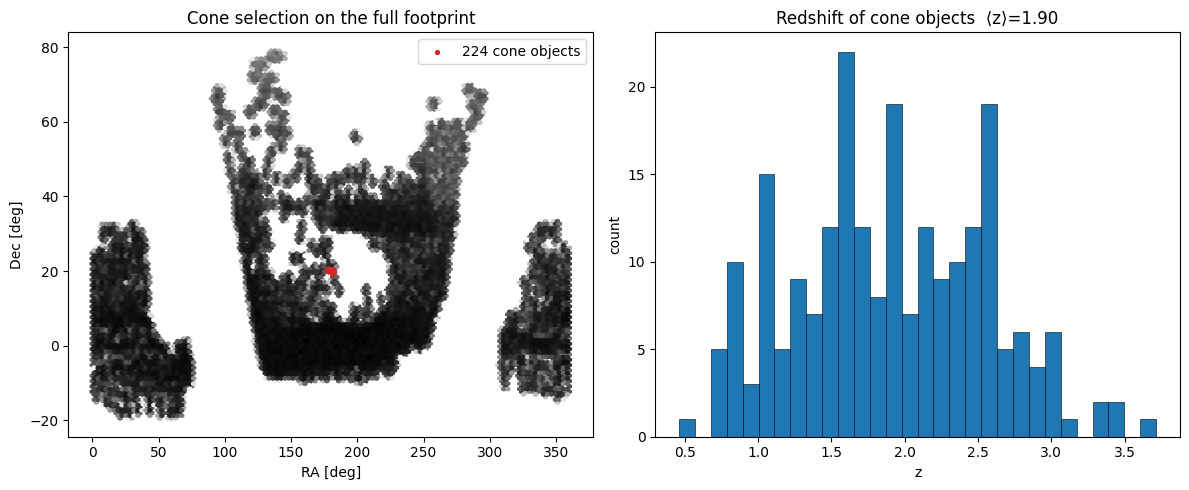

In [10]:
from oneuniverse.data.converter import read_oneuniverse_parquet

all_radec = read_oneuniverse_parquet(db.get_path(dataset), columns=['ra', 'dec'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hexbin(all_radec['ra'], all_radec['dec'], gridsize=120,
          cmap='Greys', bins='log', mincnt=1)
ax.scatter(df_lvl0['ra'], df_lvl0['dec'], s=8,
           c='C3', label=f'{len(df_lvl0)} cone objects', zorder=3)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Cone selection on the full footprint')
ax.legend()

ax = axes[1]
z_finite = df_lvl0['z'].to_numpy()
z_finite = z_finite[np.isfinite(z_finite) & (z_finite > 0)]
ax.hist(z_finite, bins=30, color='C0', edgecolor='black', linewidth=0.4)
ax.set_xlabel('z')
ax.set_ylabel('count')
ax.set_title(f'Redshift of cone objects  ⟨z⟩={z_finite.mean():.2f}')

fig.tight_layout()
plt.show()

## 5. Looking up objects across surveys

Two more useful selectors when you already know an object:

* `from_id(oneuid)` — direct lookup, raises `KeyError` if absent.
* `from_foreign_ids(dataset, [row_idx])` — useful when you have a per-survey identifier (in OUF the original row index is preserved).

Once you have the `oneuid`, `q.concurrences(uid)` returns *every* observation of that object across the database — typically a few rows for an object seen by multiple surveys.

In [11]:
# Pick the first oneuid from our cone
uid = int(uids_cone[0])
print(f'oneuid = {uid}')

rows = q.concurrences(uid)
print(f'Observed in {rows["dataset"].nunique()} dataset(s)')
rows

oneuid = 830907
Observed in 1 dataset(s)


,oneuid,dataset,row_index,ra,dec,z
0,830907,spectroscopic_desi_dr1_qso,830917,181.676303,19.364964,1.964562


In [12]:
# Round-trip: ask for the same object via from_id
assert q.from_id(uid).tolist() == [uid]

# And via from_foreign_ids using the row index in its native dataset
foreign = q.from_foreign_ids(rows['dataset'].iloc[0], [int(rows['row_index'].iloc[0])])
assert int(foreign[0]) == uid
print('Round-trip OK')

Round-trip OK


## Summary

* `Cone`, `Shell`, `SkyPatch` are reusable everywhere — pass them to a single-survey loader *or* to a `OneuidQuery`.
* `OneuidQuery` lets you separate the question ("which objects?") from the cost ("how much data?").
* The recipe is: build the index once, then **select cheaply, hydrate selectively**.

Next: combining concurrences across surveys with the `oneuniverse.combine` strategies (`best_only`, `ivar_average`, `hyperparameter`).